In [6]:
from main import load_data

import numpy as np

In [7]:
id = 's1'
P, V = load_data(id)

In [8]:
A = np.load('sample_data/s1.npy')
A

array([[2.0240419e+07, 6.4380000e+01, 6.4290000e+01, ..., 8.8410000e+05,
        6.6460000e+01, 6.4380000e+01],
       [2.0240422e+07, 6.4460000e+01, 6.4290000e+01, ..., 8.4520000e+05,
        6.3480000e+01, 6.4290000e+01],
       [2.0240423e+07, 6.4710000e+01, 6.3600000e+01, ..., 4.7450000e+05,
        3.5450000e+01, 6.4290000e+01],
       ...,
       [2.0250404e+07, 5.4800000e+01, 5.5270000e+01, ..., 2.7450000e+06,
        1.6070000e+02, 5.8850000e+01],
       [2.0250408e+07, 5.2730000e+01, 5.1410000e+01, ..., 2.6805000e+06,
        1.4697000e+02, 5.5270000e+01],
       [2.0250409e+07, 4.7830000e+01, 4.7830000e+01, ..., 2.8196000e+06,
        1.4715000e+02, 5.1410000e+01]], shape=(242, 8))

In [9]:
A

array([[2.0240419e+07, 6.4380000e+01, 6.4290000e+01, ..., 8.8410000e+05,
        6.6460000e+01, 6.4380000e+01],
       [2.0240422e+07, 6.4460000e+01, 6.4290000e+01, ..., 8.4520000e+05,
        6.3480000e+01, 6.4290000e+01],
       [2.0240423e+07, 6.4710000e+01, 6.3600000e+01, ..., 4.7450000e+05,
        3.5450000e+01, 6.4290000e+01],
       ...,
       [2.0250404e+07, 5.4800000e+01, 5.5270000e+01, ..., 2.7450000e+06,
        1.6070000e+02, 5.8850000e+01],
       [2.0250408e+07, 5.2730000e+01, 5.1410000e+01, ..., 2.6805000e+06,
        1.4697000e+02, 5.5270000e+01],
       [2.0250409e+07, 4.7830000e+01, 4.7830000e+01, ..., 2.8196000e+06,
        1.4715000e+02, 5.1410000e+01]], shape=(242, 8))

In [24]:
import pandas as pd
import numpy as np

data = pd.DataFrame({'close': P, 'volume': V})
data.head()

,close,volume
0,64.29,66.46
1,64.29,63.48
2,63.60,35.45
3,63.94,63.61
4,63.43,60.08


In [25]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(data, test_size=0.2, shuffle=False)
model = ARIMA(train_data['close'], order=(1, 1, 1))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  close   No. Observations:                  193
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -174.789
Date:                Mon, 27 Apr 2026   AIC                            355.577
Time:                        11:25:29   BIC                            365.350
Sample:                             0   HQIC                           359.535
                                - 193                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1795      0.606      0.296      0.767      -1.008       1.367
ma.L1         -0.0970      0.598     -0.162      0.871      -1.270       1.076
sigma2         0.3616      0.022     16.611      0.000       0.319       0.404
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               173.00
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.27   Skew:                             0.86
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.32
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [26]:
model_fit.aic

np.float64(355.5771730780265)

In [27]:
valid_data['close'].iloc[0]

np.float64(63.1)

In [28]:
model_fit.forecast(steps=1)

193    62.882979
dtype: float64

In [29]:
abs_errors = []
predictions = []
targets = []
for i in range(len(valid_data)):
    correct = valid_data['close'].iloc[i]
    pred = model_fit.forecast(steps=1)
    model_fit = model_fit.append([correct],refit=True)
    
    predictions.append(pred)
    targets.append(correct)
    
    error = abs(correct - pred)
    abs_errors.append(error)

abs_errors = np.array(abs_errors)
abs_errors.mean()
abs_errors.std()
predictions = np.array(predictions)
targets = np.array(targets)
print(f"Mean absolute error: {abs_errors.mean()} +/- {abs_errors.std()}")

Mean absolute error: 0.593446649636946 +/- 0.8407069281338794


/Users/phucbb/Personal/stock-prediction/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


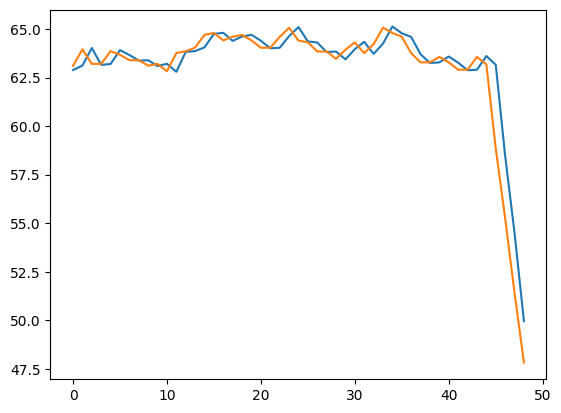

In [30]:
from matplotlib import pyplot as plt

plt.plot(predictions)    
plt.plot(targets)

In [ ]:
data.close.rolling(window=5).mean()

In [ ]:
data.to_csv('data.csv', index=False)